In [38]:
#I installed the necessary libraries and settings.
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops, hog
from skimage.filters import gabor
from skimage.util import img_as_ubyte
from scipy.stats import entropy, skew, kurtosis
from scipy.signal import correlate2d
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import jaccard_score, confusion_matrix
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.utils import resample
from tqdm import tqdm
import time
import warnings
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from joblib import Parallel, delayed
import joblib
from collections import Counter
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
warnings.filterwarnings("ignore")
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import ExtraTreesClassifier
from datetime import datetime
import pandas as pd
import seaborn as sns
from scipy.signal import correlate2d

In [2]:

print(datetime.now().strftime("%d-%m-%Y %H:%M:%S"))
print("Cavit Eren YILDIZ -- 201805001")


04-06-2025 17:54:48
Cavit Eren YILDIZ -- 201805001


In [3]:
# --- 1. Load Images and Convert to Grayscale ---
image = cv2.imread("input.png", cv2.IMREAD_GRAYSCALE)
mask = cv2.imread("mask.png", cv2.IMREAD_GRAYSCALE)

In [4]:
#************************** Feature extraction function ***************************

In [5]:
def extract_advanced_features(image, mask, window_size=5, var_threshold=1e-6, indices=None):
    if window_size % 2 == 0:
        raise ValueError("window_size must be an odd number.")

    pad = window_size // 2
    image_padded = np.pad(image, pad, mode='reflect')
    mask_padded = np.pad(mask, pad, mode='reflect')

    features, labels = [], []

    # Eğer indices verilmemişse tüm pikselleri kullan
    if indices is None:
        rows = range(pad, pad + image.shape[0])
        cols = range(pad, pad + image.shape[1])
        indices = [(i, j) for i in rows for j in cols]
    else:
        # Indeksler orijinal image koordinatlarında, padding ekle
        indices = [(i + pad, j + pad) for (i, j) in indices]

    for (i, j) in tqdm(indices, desc="Extracting features"):
        window = image_padded[i - pad:i + pad + 1, j - pad:j + pad + 1]
        label = mask_padded[i, j]

        win_mean = np.mean(window)
        win_std = np.std(window)

        if win_std < var_threshold:
            continue

        norm_window = (window - win_mean) / (win_std + 1e-8)

        lbp = local_binary_pattern(norm_window, P=8, R=1, method='uniform')
        lbp_hist, _ = np.histogram(lbp, bins=np.arange(0, 11), density=True)

        hist, _ = np.histogram(window, bins=256, range=(0, 255), density=True)
        hist += 1e-8
        entr = entropy(hist, base=2)

        sobel_x = cv2.Sobel(norm_window, cv2.CV_64F, 1, 0, ksize=3)
        sobel_y = cv2.Sobel(norm_window, cv2.CV_64F, 0, 1, ksize=3)
        sobel_mag = np.sqrt(sobel_x ** 2 + sobel_y ** 2).mean()

        glcm = graycomatrix(window.astype(np.uint8), distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
        contrast = graycoprops(glcm, 'contrast')[0, 0]
        correlation = graycoprops(glcm, 'correlation')[0, 0]
        energy = graycoprops(glcm, 'energy')[0, 0]
        homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]

        median_val = np.median(window)
        skewness = skew(window.flatten())
        kurt = kurtosis(window.flatten())

        feature_vector = np.concatenate([
            lbp_hist,
            [entr, win_mean, win_std, median_val, skewness, kurt, sobel_mag],
            [contrast, correlation, energy, homogeneity]
        ])

        if np.isnan(feature_vector).any():
            continue

        features.append(feature_vector)
        labels.append(label)

    return np.array(features), np.array(labels)


In [6]:
#***************We find the best model and window as an example from the data********************

In [7]:
# --- Model Definitions ---
models = {

    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=13),
    'Decision Tree': DecisionTreeClassifier(random_state=13),
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=13),
    'KNN': KNeighborsClassifier(n_neighbors=5),

}

# Window sizes to evaluate
window_sizes = [5, 11, 19]
overall_results = {}

# Loop through each window size
for ws in window_sizes:
    print(f"\n Extracting features with window size = {ws}")
    
    # Extract features and labels using texture-based descriptors
    features, labels = extract_advanced_features(image, mask, window_size=ws)

    # Sample a fraction of the data (e.g. 20%) for training/testing
    sample_frac = 0.2
    sample_indices = np.random.choice(len(features), int(len(features) * sample_frac), replace=False)
    X_sample = features[sample_indices]
    y_sample = labels[sample_indices]

    #  Filter out classes with fewer than 2 samples
    min_samples_per_class = 2
    class_counts = Counter(y_sample)
    valid_classes = [cls for cls, count in class_counts.items() if count >= min_samples_per_class]

    valid_mask = np.isin(y_sample, valid_classes)
    X_sample_filtered = X_sample[valid_mask]
    y_sample_filtered = y_sample[valid_mask]

    # If not enough data after filtering, skip this window size
    if len(np.unique(y_sample_filtered)) < 2:
        print(f" Not enough valid classes with >=2 samples for window size {ws}. Skipping...")
        continue

    # Stratified train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_sample_filtered, y_sample_filtered,
        test_size=0.2, random_state=13, stratify=y_sample_filtered
    )

    # Train and evaluate each model
    for name, model in models.items():
        print(f"   Training {name} on window size {ws}...")
        
        # Measure training time
        t0 = time.time()
        model.fit(X_train, y_train)
        t1 = time.time()
        train_time = t1 - t0

        # Measure test prediction time
        t0 = time.time()
        y_pred = model.predict(X_test)
        t1 = time.time()
        test_time = t1 - t0

        # Compute IoU score (Jaccard Index)
        iou = jaccard_score(y_test, y_pred, average='weighted')

        # Save results for current model and window size
        key = f"{name} | window={ws}"
        overall_results[key] = {
            'model': model,
            'iou': iou,
            'train_time': train_time,
            'test_time': test_time,
            'window_size': ws,
            'model_name': name
        }

# --- Print Results Summary ---
print("\n All Model and Window Size Results:")
for key, res in overall_results.items():
    print(f"- {key}: IoU = {res['iou']:.4f} | Train = {res['train_time']:.2f}s | Test = {res['test_time']:.2f}s")

# --- Select and Report Best Combination ---
if overall_results:
    best_key = max(overall_results, key=lambda k: overall_results[k]['iou'])
    best_result = overall_results[best_key]

    print(f"\n Best combination: {best_result['model_name']} (window={best_result['window_size']})")
    print(f"   - IoU: {best_result['iou']:.4f}")
    print(f"   - Training time: {best_result['train_time']:.2f} seconds")
    print(f"   - Test time: {best_result['test_time']:.2f} seconds")
else:
    print(" No valid model evaluations. All window sizes may have been skipped due to class imbalance.")


 Extracting features with window size = 5


Extracting features: 100%|██████████████████████████████████████████████████| 1228800/1228800 [44:35<00:00, 459.22it/s]


   Training Random Forest on window size 5...
   Training Decision Tree on window size 5...
   Training Logistic Regression on window size 5...
   Training KNN on window size 5...


  File "C:\Users\cav1t\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\cav1t\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\cav1t\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\cav1t\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^



 Extracting features with window size = 11


Extracting features: 100%|██████████████████████████████████████████████████| 1228800/1228800 [39:35<00:00, 517.22it/s]


   Training Random Forest on window size 11...
   Training Decision Tree on window size 11...
   Training Logistic Regression on window size 11...
   Training KNN on window size 11...

 Extracting features with window size = 19


Extracting features: 100%|██████████████████████████████████████████████████| 1228800/1228800 [37:30<00:00, 546.11it/s]


   Training Random Forest on window size 19...
   Training Decision Tree on window size 19...
   Training Logistic Regression on window size 19...
   Training KNN on window size 19...

 All Model and Window Size Results:
- Random Forest | window=5: IoU = 0.5984 | Train = 85.20s | Test = 1.06s
- Decision Tree | window=5: IoU = 0.4933 | Train = 5.85s | Test = 0.01s
- Logistic Regression | window=5: IoU = 0.4281 | Train = 20.81s | Test = 0.00s
- KNN | window=5: IoU = 0.5177 | Train = 0.01s | Test = 4.66s
- Random Forest | window=11: IoU = 0.7908 | Train = 90.88s | Test = 0.72s
- Decision Tree | window=11: IoU = 0.6746 | Train = 6.78s | Test = 0.01s
- Logistic Regression | window=11: IoU = 0.4733 | Train = 17.96s | Test = 0.01s
- KNN | window=11: IoU = 0.6403 | Train = 0.01s | Test = 3.92s
- Random Forest | window=19: IoU = 0.9316 | Train = 92.25s | Test = 0.55s
- Decision Tree | window=19: IoU = 0.8522 | Train = 6.75s | Test = 0.01s
- Logistic Regression | window=19: IoU = 0.5534 | Train 

In [8]:
#**************** Feature extraction for training model **************************

In [15]:
# 1. Select valid classes (those with at least 2 samples)
all_indices = [(i, j) for i in range(mask.shape[0]) for j in range(mask.shape[1]) if mask[i, j] != 0]
all_labels = [mask[i,j] for (i,j) in all_indices]
class_counts = Counter(all_labels)
valid_classes = [cls for cls, count in class_counts.items() if count >= 2]
valid_indices = [(i,j) for (i,j) in all_indices if mask[i,j] in valid_classes]
valid_labels = [mask[i,j] for (i,j) in valid_indices]

# 2. Perform train-test split
train_indices, test_indices = train_test_split(valid_indices, test_size=0.2, random_state=13, stratify=valid_labels)

# 3. Extract features ONLY for training data using training indices
features_train_raw, labels_train = extract_advanced_features(
    image, mask, window_size=19, indices=train_indices
)

Extracting features: 100%|████████████████████████████████████████████████████| 983038/983038 [29:14<00:00, 560.22it/s]


In [16]:
#************************* Data allocated for training control *****************

In [17]:
# Print unique classes in the training labels along with their counts
print("Training classes:", np.unique(labels_train, return_counts=True))

# Print the shape of the training features array
print("features_train_raw shape:", features_train_raw.shape)

# Print the shape of the training labels array
print("labels_train shape:", labels_train.shape)

# Check if there are any NaN values in the training features
print("Any NaN values in features:", np.isnan(features_train_raw).any())

# Check if there are any infinite values in the training features
print("Any infinite values in features:", np.isinf(features_train_raw).any())


Training classes: (array([ 76,  90, 100, 121, 134, 139, 150, 170], dtype=uint8), array([226676, 269876,    293,    460,     51,    460,    383, 484839],
      dtype=int64))
features_train_raw shape: (983038, 21)
labels_train shape: (983038,)
Any NaN values in features: False
Any infinite values in features: False


In [18]:
#***************** Model training *******************

In [19]:
# Pipeline definition (will fit only on training data)

pipeline = Pipeline([
    ('scaler', StandardScaler()),            #  Normalization
    ('clf', RandomForestClassifier(n_estimators=100, random_state=13))
])

# 3. Do the training (scaler,model fit) and measure the timestart_train = time.time()
start_train = time.time()
pipeline.fit(features_train_raw, labels_train)
end_train = time.time()

train_time = end_train - start_train
print(f" Training time: {train_time:.2f} seconds")



 Training time: 567.22 seconds


In [20]:
#************ Test feature extraction and prediction score calculation ***************


In [21]:
# Feature extraction for testing
features_test_raw, labels_test = extract_advanced_features(
    image, mask, window_size=19, indices=test_indices
)

# Estimation and test time measurement
start_test = time.time()
y_pred = pipeline.predict(features_test_raw)
end_test = time.time()
test_time = end_test - start_test
print(f" Test tahmin süresi: {test_time:.4f} saniye")

#  save the model:
joblib.dump(pipeline, 'texture_pipeline.pkl')
iou = jaccard_score(labels_test, y_pred, average='weighted')
print(f"IoU score: {iou:.4f}")

Extracting features: 100%|████████████████████████████████████████████████████| 245760/245760 [07:08<00:00, 573.23it/s]


 Test tahmin süresi: 3.9862 saniye
IoU score: 0.9703


In [22]:
#************** Feature importance plots ****************

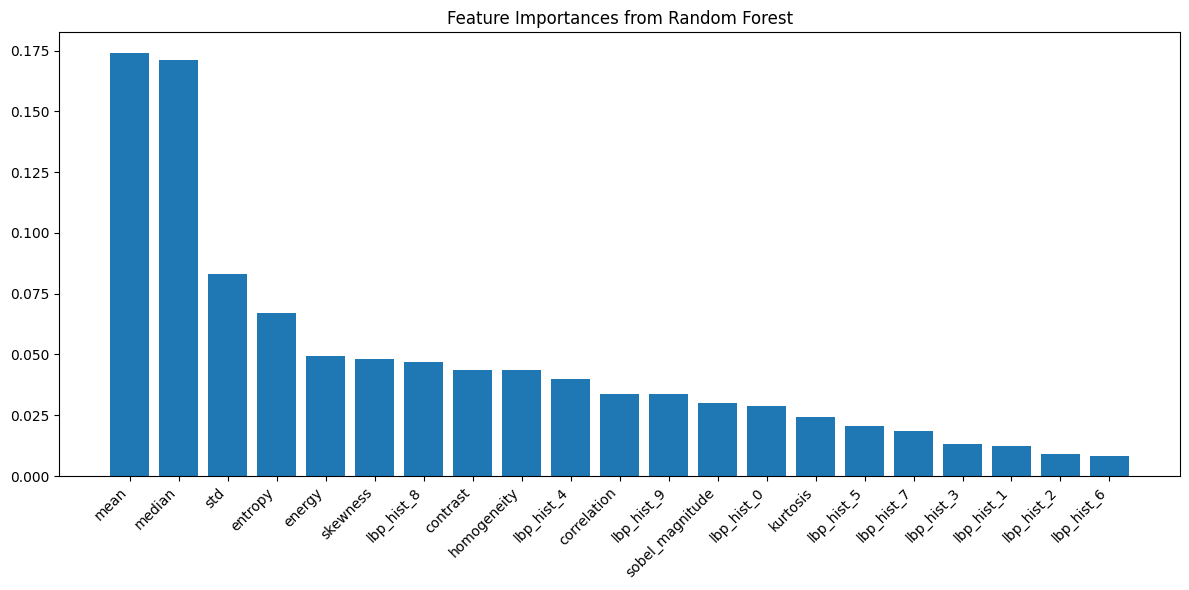

In [23]:
feature_names = [
    *[f'lbp_hist_{i}' for i in range(10)],
    'entropy', 'mean', 'std', 'median', 'skewness', 'kurtosis', 'sobel_magnitude',
    'contrast', 'correlation', 'energy', 'homogeneity'
]

#  model in pipeline
rf = pipeline.named_steps['clf']

#  feature importances
importances = rf.feature_importances_

# Sort by (most important first)
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(12,6))
plt.title("Feature Importances from Random Forest")
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [24]:
#Creating a new mask image from the prediction data by extracting features and comparing them.

In [25]:
# Get coordinates of all valid pixels (mask != 0)
all_valid_coords = [(i, j) for i in range(mask.shape[0]) for j in range(mask.shape[1]) if mask[i, j] != 0]

# Get features for these coordinates
features_all, _ = extract_advanced_features(image, mask, window_size=19, var_threshold=1e-6, indices=all_valid_coords)


Extracting features: 100%|██████████████████████████████████████████████████| 1228800/1228800 [40:19<00:00, 507.84it/s]


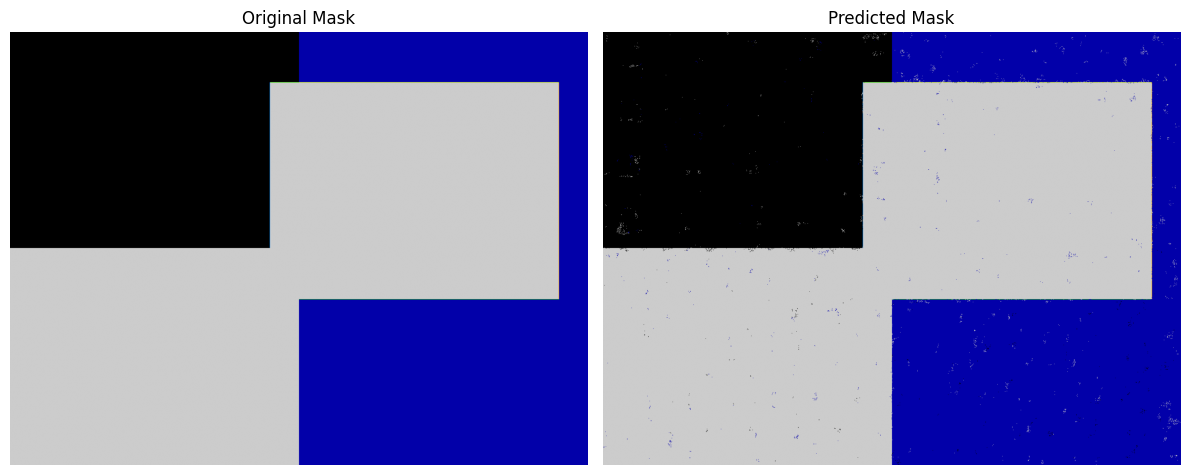

In [26]:
# Make predictions with the model (pipeline)
predicted_labels = pipeline.predict(features_all)

# Create new mask and place predictions
predicted_mask = np.zeros_like(mask)

for (i, j), label in zip(all_valid_coords, predicted_labels):
    predicted_mask[i, j] = label

# Visualize original and prediction mask

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Original Mask")
plt.imshow(mask, cmap='nipy_spectral')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Predicted Mask")
plt.imshow(predicted_mask, cmap='nipy_spectral')
plt.axis('off')

plt.tight_layout()
plt.show()

 Final IoU Score on full image: 0.9940


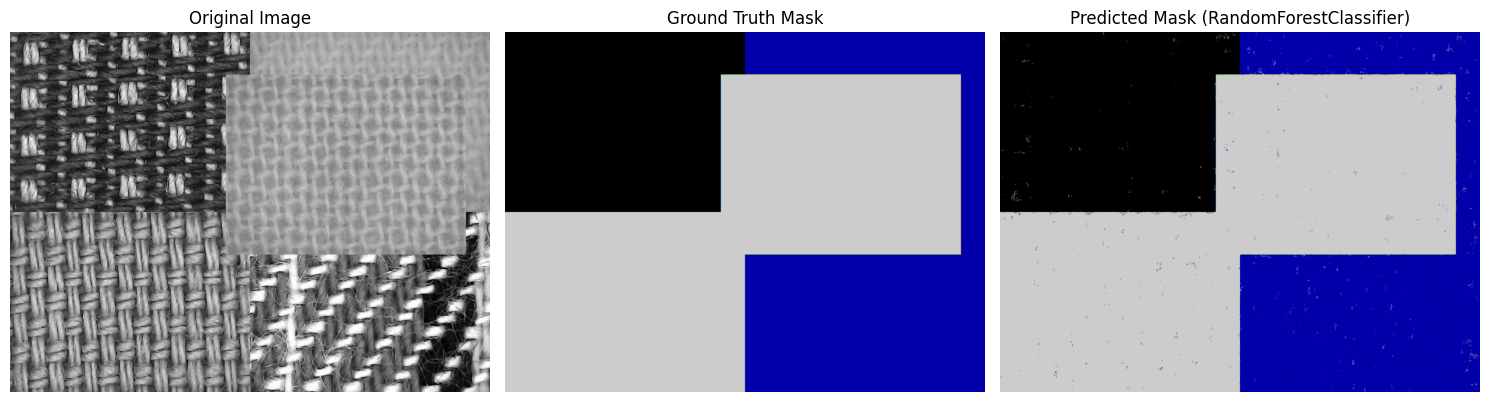

In this example, the model generated predictions for every pixel in the entire image,
and the IoU score was calculated over the whole image to assess segmentation performance.


In [27]:
# ---  IoU and Visual Result ---
final_iou = jaccard_score(mask.flatten(), predicted_mask.flatten(), average='weighted')
print(f" Final IoU Score on full image: {final_iou:.4f}")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Ground Truth Mask")
plt.imshow(mask, cmap='nipy_spectral')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title(f"Predicted Mask ({type(pipeline.named_steps['clf']).__name__})")
plt.imshow(predicted_mask, cmap='nipy_spectral')
plt.axis('off')

plt.tight_layout()
plt.show()

print("In this example, the model generated predictions for every pixel in the entire image,")
print("and the IoU score was calculated over the whole image to assess segmentation performance.")



<Figure size 800x600 with 0 Axes>

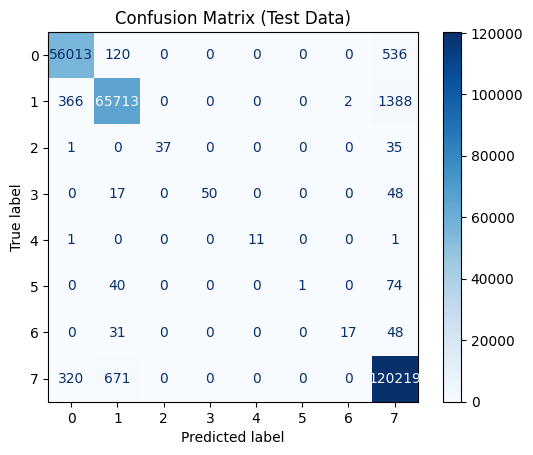

In [28]:
# Confusion matrix on test data
cm = confusion_matrix(labels_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix (Test Data)")
plt.show()


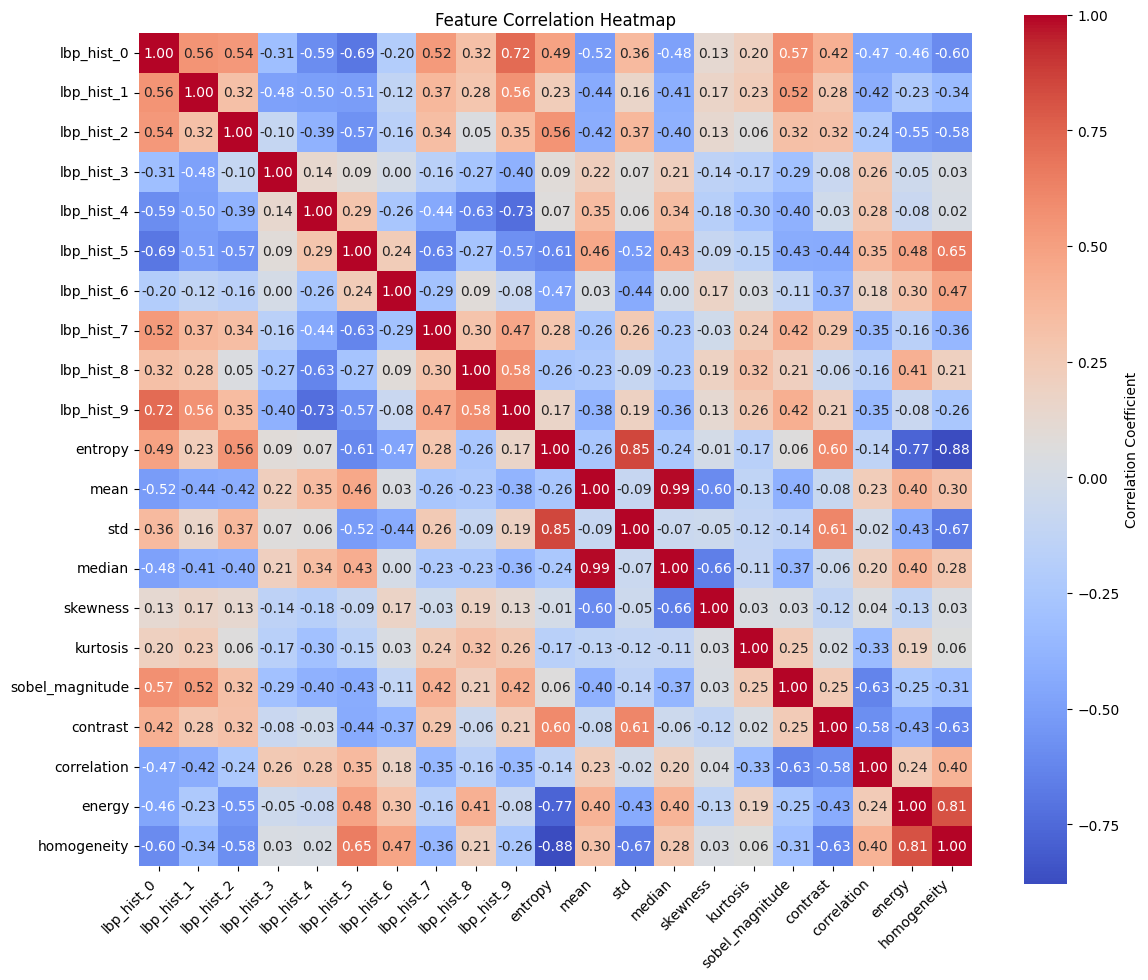

In [36]:
# Feature names
feature_names = [
    *[f'lbp_hist_{i}' for i in range(10)],
    'entropy', 'mean', 'std', 'median', 'skewness', 'kurtosis', 'sobel_magnitude',
    'contrast', 'correlation', 'energy', 'homogeneity'
]

# Convert to DataFrame
df_features = pd.DataFrame(X_train, columns=feature_names)

# Calculate the correlation matrix
corr_matrix = df_features.corr()

# Heatmap drawing
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True,
            xticklabels=feature_names, yticklabels=feature_names, cbar_kws={'label': 'Correlation Coefficient'})
plt.title("Feature Correlation Heatmap")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


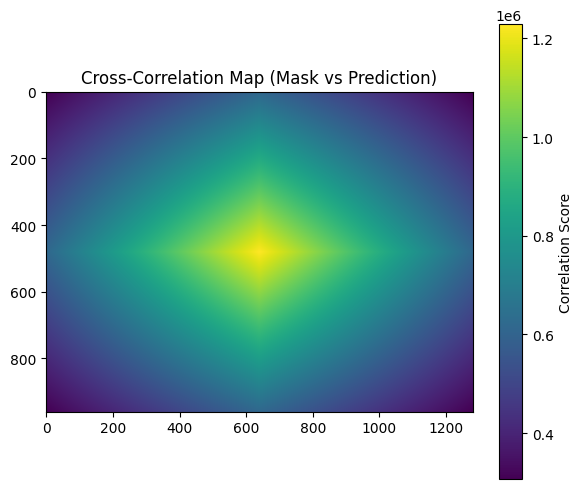

In [40]:
# Convert the original and predicted masks to binary (1 where class present, 0 elsewhere)
# This simplifies comparison to foreground vs background pixels
mask_binary = (mask > 0).astype(float)
predicted_binary = (predicted_mask > 0).astype(float)

# Compute 2D cross-correlation between the binary masks
# This measures local similarity / overlap between the ground truth and prediction
# 'same' mode ensures output has the same shape as input masks
cross_corr = correlate2d(mask_binary, predicted_binary, mode='same')

# Visualize the cross-correlation map
plt.figure(figsize=(6, 5))
plt.title("Cross-Correlation Map (Mask vs Prediction)")
plt.imshow(cross_corr, cmap='viridis')  # Use 'viridis' colormap for better visual contrast
plt.colorbar(label="Correlation Score")  # Add color bar to indicate correlation magnitude
plt.tight_layout()
plt.show()



Top 5 features: ['mean', 'median', 'std', 'entropy', 'energy']


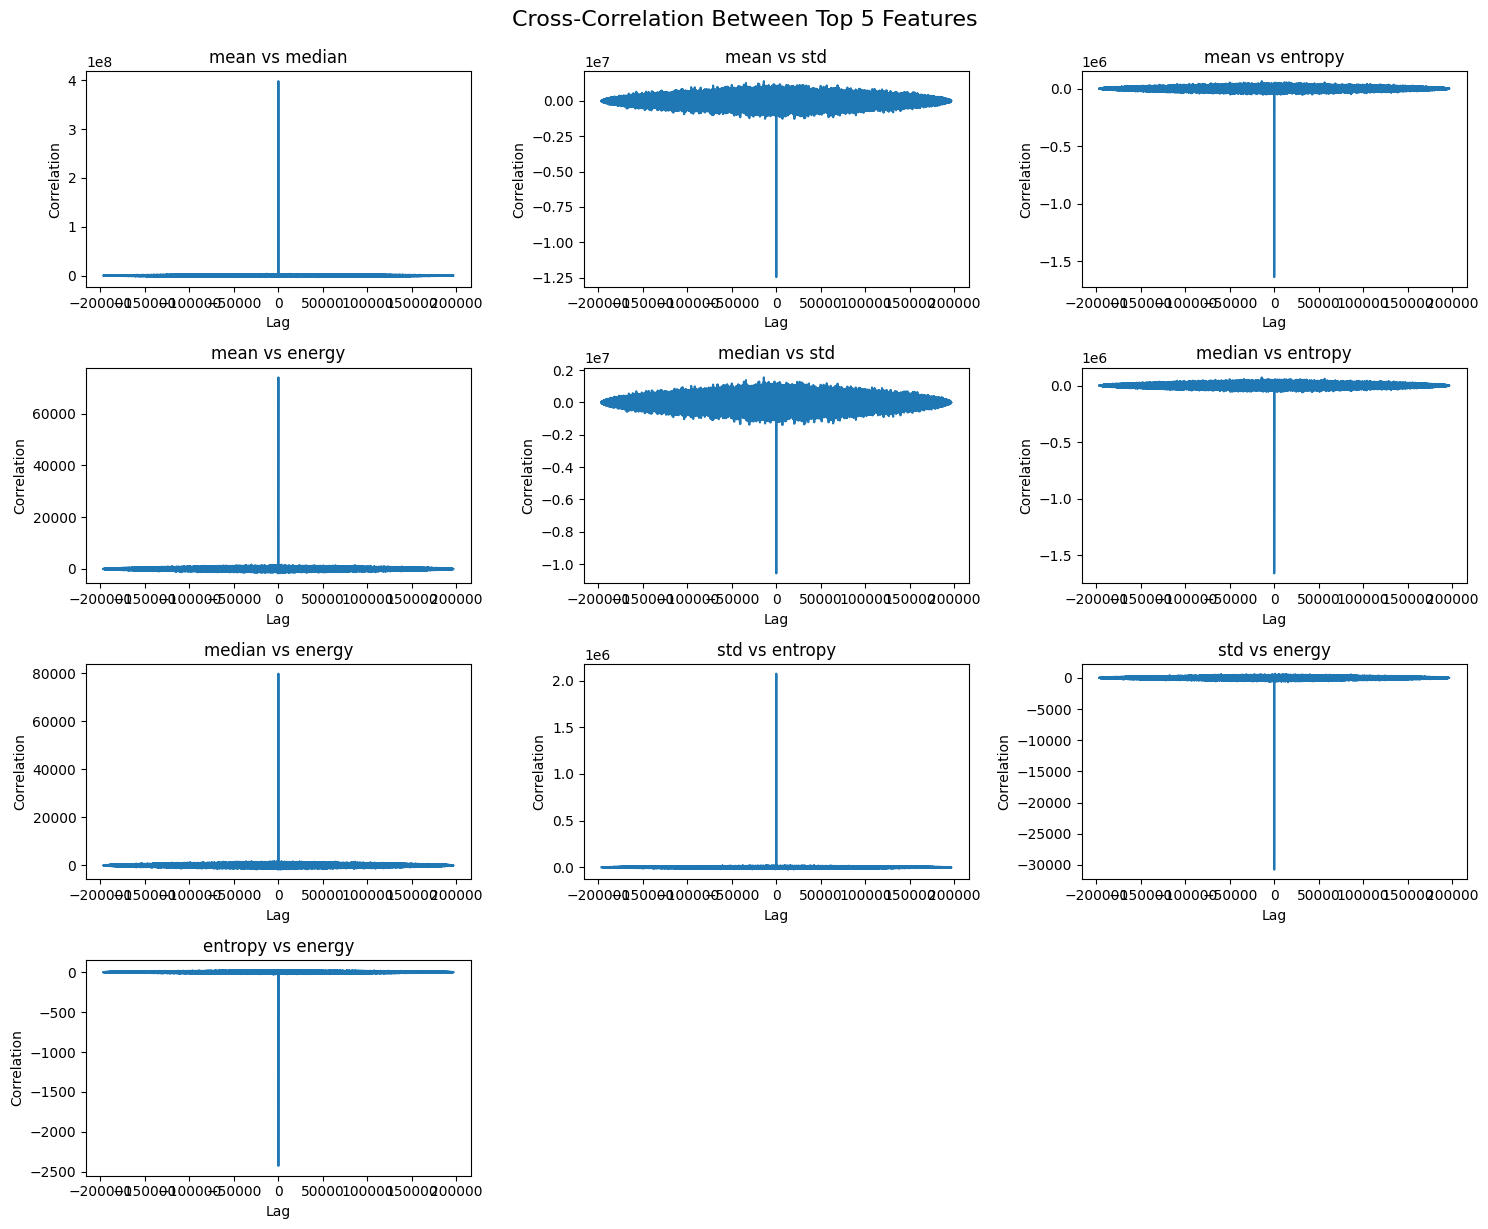

In [48]:
# 1. Feature names (zaten var)
feature_names = [
    *[f'lbp_hist_{i}' for i in range(10)],
    'entropy', 'mean', 'std', 'median', 'skewness', 'kurtosis', 'sobel_magnitude',
    'contrast', 'correlation', 'energy', 'homogeneity'
]

# 2. Feature importances from Random Forest in pipeline
rf = pipeline.named_steps['clf']
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# 3. En önemli 5 özelliği seç
top_5_indices = indices[:5]
top_5_features = [feature_names[i] for i in top_5_indices]
print("Top 5 features:", top_5_features)

# 4. Eğitim verisini DataFrame'e çevir
df_features = pd.DataFrame(X_train, columns=feature_names)

# 5. Cross-correlation hesaplama ve çizim
plt.figure(figsize=(15, 12))
plot_idx = 1

for i in range(len(top_5_features)):
    for j in range(i + 1, len(top_5_features)):
        f1, f2 = top_5_features[i], top_5_features[j]
        sig1 = df_features[f1].values - np.mean(df_features[f1].values)
        sig2 = df_features[f2].values - np.mean(df_features[f2].values)

        corr = correlate(sig1, sig2, mode='full')
        lags = np.arange(-len(sig1) + 1, len(sig1))

        # subplot(4, 3, ...) = 12 hücre (10 grafik için yeterli)
        plt.subplot(4, 3, plot_idx)
        plt.plot(lags, corr)
        plt.title(f"{f1} vs {f2}")
        plt.xlabel("Lag")
        plt.ylabel("Correlation")
        plot_idx += 1

plt.tight_layout()
plt.suptitle("Cross-Correlation Between Top 5 Features", fontsize=16, y=1.02)
plt.show()
